**Importing Necessary Dependencies**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

**Problem 1**  

**Creating Train and Test Splits**

In [14]:
rng = np.random.default_rng(seed=1)
twomoon_data = np.loadtxt('twomoonsdataset.txt', delimiter="\t")
rng.shuffle(twomoon_data)

X_train, y_train = (twomoon_data[:int(twomoon_data.shape[0] * 0.8), :2], twomoon_data[:int(twomoon_data.shape[0] * 0.8), 2].reshape(-1, 1))
X_test, y_test = (twomoon_data[int(twomoon_data.shape[0] * 0.8):, :2], twomoon_data[int(twomoon_data.shape[0] * 0.8):, 2].reshape(-1, 1))

X_min=np.min(X_train)
X_max=np.max(X_train)

X_train = (X_train - X_min) / (X_max - X_min)

X_test = (X_test - X_min) / (X_max - X_min)


X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

# print(X_train.shape)
# print(y_train.shape)

**Defining SVM Gradient and Gradient Descent Function**

In [15]:
def loss_function_subgradient(w, X, y, lambda_=1):
    non_zero_values = ((1 - (y * (X@w).reshape(-1,1))) > 0).flatten()
    return w + (lambda_) * (-np.sum(y[non_zero_values] * X[non_zero_values], axis=0))

def svm_subgradient_descent(w, X, y, lambda_=1, step_size=0.001, stop_cond=0.001, max_iterations=2000000):
    iterations = 0
    subgradient_norm = []
    for _ in range(max_iterations):
        iterations += 1
        subgrad = loss_function_subgradient(w, X, y, lambda_)
        subgrad_norm = np.linalg.norm(subgrad)
        subgradient_norm.append(subgrad_norm)
        w = w - (step_size / (2 * (iterations + 1))) * subgrad
        if subgrad_norm < stop_cond:
            return (w, iterations, subgradient_norm)
    return (w, iterations, subgradient_norm)

**Running Initial Non-Kernal SVM on Train and Test**

Gradient Descent (Momentum) Final Value: [ 0.89313469  2.51043999 -4.92574008] over 100000 iterations.


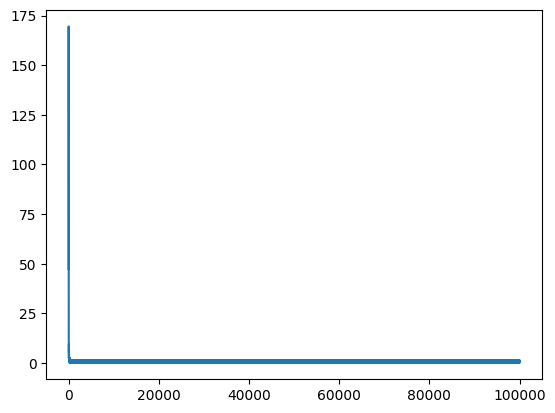

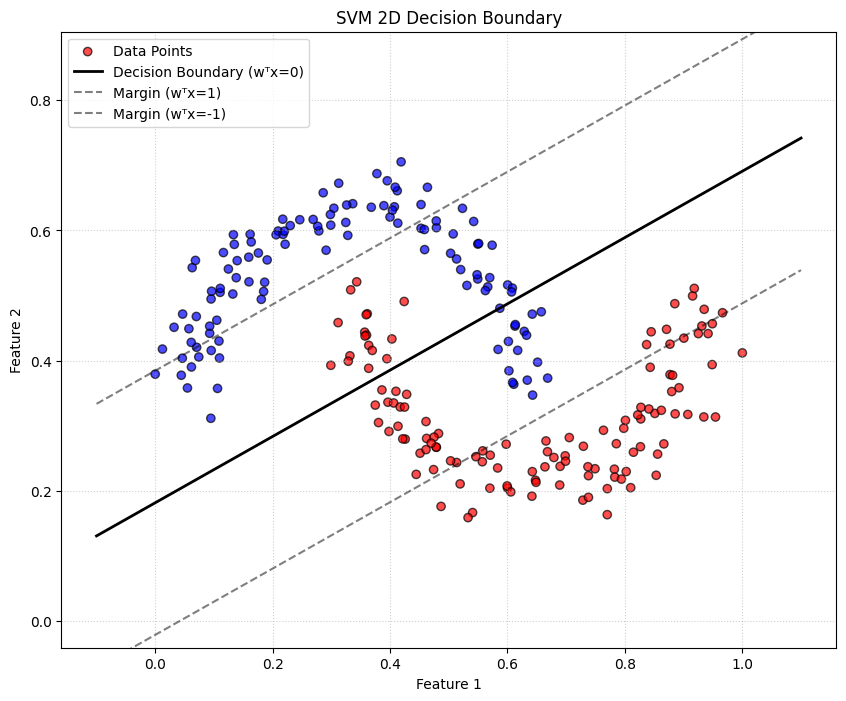

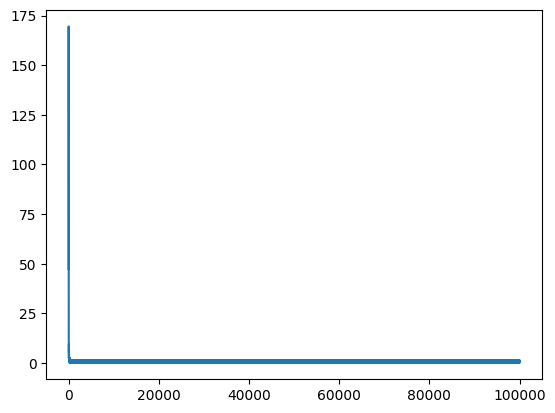

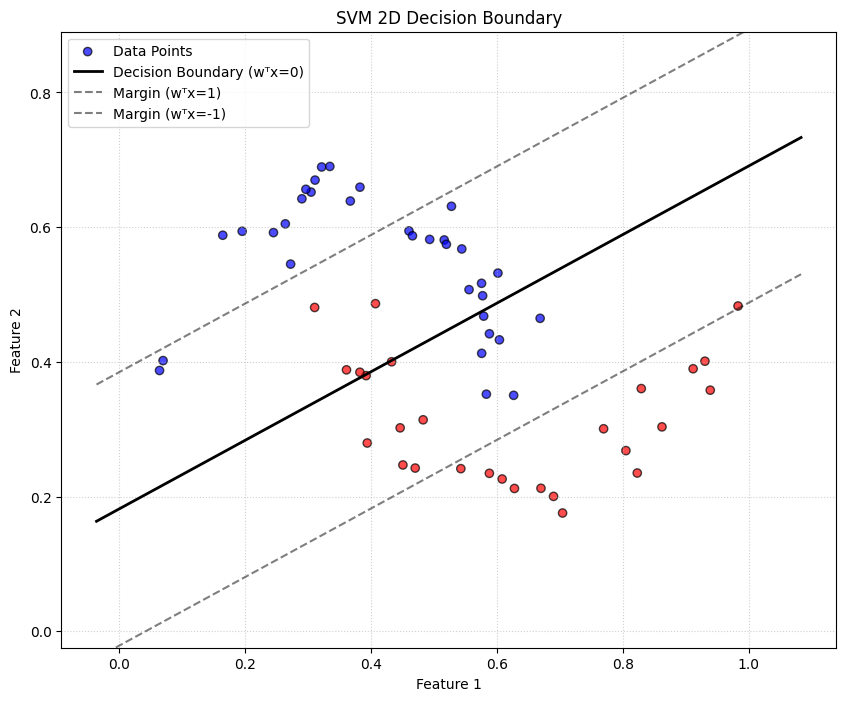

0.8166666666666667


In [16]:
subgradient_val = svm_subgradient_descent(np.array([0,0,0]), X_train, y_train, step_size=1, stop_cond=0.01, lambda_=1, max_iterations=100000)
print("Gradient Descent (Momentum) Final Value:", subgradient_val[0], "over", subgradient_val[1], "iterations.")
plt.plot([i for i in range(subgradient_val[1])], subgradient_val[2])
# plt.ylim(top=3.5, bottom=0)
plt.show()

bias = subgradient_val[0][0]
w1 = subgradient_val[0][1]
w2 = subgradient_val[0][2]

plt.figure(figsize=(10, 8))

plt.scatter(X_train[:, 1], X_train[:, 2], c=y_train, cmap='bwr', alpha=0.7, edgecolors='k', label='Data Points')

x1_range = np.linspace(X_train[:, 1].min() - 0.1, X_train[:, 1].max() + 0.1, 100)
x2_boundary = -(w1 * x1_range + bias) / w2

x2_margin_plus = -(w1 * x1_range + bias - 1) / w2
x2_margin_minus = -(w1 * x1_range + bias + 1) / w2

plt.plot(x1_range, x2_boundary, 'k-', linewidth=2, label='Decision Boundary (wᵀx=0)')
plt.plot(x1_range, x2_margin_plus, 'k--', alpha=0.5, label='Margin (wᵀx=1)')
plt.plot(x1_range, x2_margin_minus, 'k--', alpha=0.5, label='Margin (wᵀx=-1)')

plt.title(f'SVM 2D Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.ylim(X_train[:, 2].min() - 0.2, X_train[:, 2].max() + 0.2)

plt.show()

plt.plot([i for i in range(subgradient_val[1])], subgradient_val[2])
plt.show()
plt.close()

plt.figure(figsize=(10, 8))

plt.scatter(X_test[:, 1], X_test[:, 2], c=y_test, cmap='bwr', alpha=0.7, edgecolors='k', label='Data Points')

x1_range = np.linspace(X_test[:, 1].min() - 0.1, X_test[:, 1].max() + 0.1, 100)
x2_boundary = -(w1 * x1_range + bias) / w2

x2_margin_plus = -(w1 * x1_range + bias - 1) / w2
x2_margin_minus = -(w1 * x1_range + bias + 1) / w2

plt.plot(x1_range, x2_boundary, 'k-', linewidth=2, label='Decision Boundary (wᵀx=0)')
plt.plot(x1_range, x2_margin_plus, 'k--', alpha=0.5, label='Margin (wᵀx=1)')
plt.plot(x1_range, x2_margin_minus, 'k--', alpha=0.5, label='Margin (wᵀx=-1)')

plt.title(f'SVM 2D Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.ylim(X_test[:, 2].min() - 0.2, X_test[:, 2].max() + 0.2)

plt.show()

predictions=np.sign(X_test@subgradient_val[0])

accuracy=np.mean(predictions.flatten()==y_test.flatten())

print(accuracy)


**Defining Kernel Function and Testing**

Gradient Descent (RBG Kernel) Final Value: [ 0.05694852 -0.05783403  0.05958896  0.00674945 -0.01185415 -0.02485404
 -0.02114209 -0.05217942  0.05061834  0.02630424  0.05414146 -0.03764111
  0.00857712  0.05143749 -0.06102276  0.0305336   0.04471009  0.00762045
 -0.01372988  0.0206609   0.03119389 -0.03735112  0.02298951  0.02963009
  0.05882895  0.04898536  0.05338595  0.04399789  0.06157334  0.01881614
  0.05144672  0.01798307 -0.041121   -0.01119751 -0.04306661  0.00882987
  0.02342894 -0.05748169  0.05302869 -0.04835062 -0.05970801  0.06372291
 -0.0475278  -0.03319867 -0.00501742  0.05714383 -0.00854952 -0.0348772
 -0.0222477  -0.022116    0.04874225 -0.04736736 -0.0513583  -0.02319569
 -0.00680725  0.05115888 -0.05359175  0.05921278 -0.03203152 -0.05152726
  0.04794332  0.02912146 -0.0570792   0.0457943   0.02542543 -0.01214442
  0.02701793 -0.05738153 -0.03674279  0.02082657  0.05256134  0.02416553
  0.01852224 -0.03207624  0.05198625 -0.06039115 -0.0446705   0.05327387
  0.00400

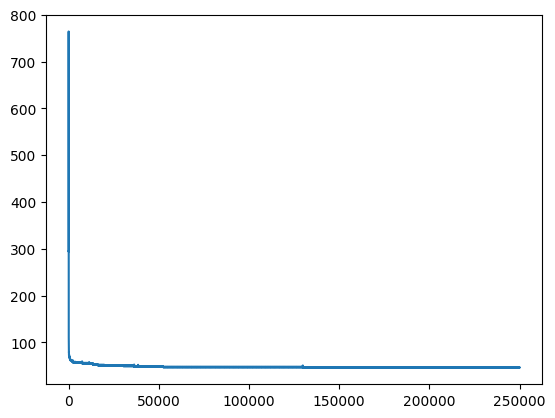

0.7166666666666667
Gradient Descent (Polynomial Kernel) Final Value: [ 1.28544496e-02 -1.70026864e-02  2.03268286e-02  3.42924725e-02
  2.67525907e-02 -7.23241044e-03  8.83310815e-03 -1.58347734e-02
  1.75551906e-02  4.39655510e-02  3.64559614e-02 -3.31227556e-02
 -8.75417139e-03  3.45213066e-02 -2.73553137e-02  4.50234594e-02
  5.13253182e-02  3.99150437e-02 -1.98316101e-02 -4.74347378e-02
 -3.05698647e-02 -8.86890754e-03  4.68093403e-02  4.89272579e-02
  2.58937508e-02  1.09359640e-03  2.77864798e-02 -1.18885876e-02
  2.27693410e-02 -5.05264167e-02 -2.29391441e-03  4.62394729e-02
  4.98076279e-04 -1.60257466e-02 -1.23585790e-03  3.81850382e-02
  1.13254557e-02 -2.05086255e-02 -7.87975331e-04 -1.14375055e-02
 -2.22474802e-02  2.72332478e-02 -2.18204061e-02 -3.69690975e-02
  2.55419867e-02  8.12054459e-03 -2.14504822e-02 -1.19303143e-02
  1.32918017e-02  1.36607294e-02 -1.86467215e-03 -1.53386489e-02
 -9.97427512e-03 -3.24434584e-02 -2.14301309e-02  2.36686215e-02
 -3.26626477e-02  1.1

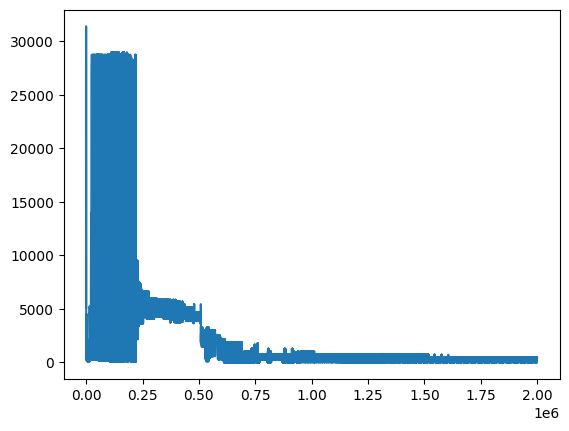

0.8666666666666667


In [17]:
def RBF(X1, X2, gamma=0.1):
    X_dot_product = X1@X2.T
    X1_sq_norm = np.sum(X1**2, axis=1).reshape(-1,1)
    X2_sq_norm = np.sum(X2**2, axis=1).reshape(-1,1)
    X_sq_distances = (X1_sq_norm + X2_sq_norm.T) - 2 * X_dot_product
    return np.exp(-gamma * X_sq_distances)

def poly(X1, X2, degree=3, gamma=1, coef0=1.0):
    X_dot_product = X1@X2.T 

    return (gamma * X_dot_product + coef0) ** degree

K_train = RBF(X_train, X_train, 1)
subgradient_val = svm_subgradient_descent(np.zeros((X_train.shape[0],)), K_train, y_train, step_size=0.001, stop_cond=0.01, lambda_=1, max_iterations=250000)
print("Gradient Descent (RBG Kernel) Final Value:", subgradient_val[0], "over", subgradient_val[1], "iterations.")
plt.plot([i for i in range(subgradient_val[1])], subgradient_val[2])
plt.show()

new_w = subgradient_val[0]
K_test = RBF(X_test, X_train, 1)
predictions = np.sign(K_test@new_w)
accuracy = np.mean(predictions.flatten()==y_test.flatten())
print(accuracy)

K_train = poly(X_train, X_train)
subgradient_val = svm_subgradient_descent(np.zeros((X_train.shape[0],)), K_train, y_train, step_size=0.75, stop_cond=0.01, lambda_=1, max_iterations=2000000)
print("Gradient Descent (Polynomial Kernel) Final Value:", subgradient_val[0], "over", subgradient_val[1], "iterations.")
plt.plot([i for i in range(subgradient_val[1])], subgradient_val[2])
plt.show()

new_w = subgradient_val[0]
K_test = poly(X_test, X_train)
predictions = np.sign(K_test@new_w)
accuracy = np.mean(predictions.flatten()==y_test.flatten())
print(accuracy)

**Problem 2**

**Creating Train and Test Splits**

In [18]:
diabetes_data = np.loadtxt("Diabetes.data.csv", delimiter=',')

X_train, y_train = (diabetes_data[:int(diabetes_data.shape[0] * 0.8), :8], diabetes_data[:int(diabetes_data.shape[0] * 0.8), 8].reshape(-1, 1))
X_test, y_test = (diabetes_data[int(diabetes_data.shape[0] * 0.8):, :8], diabetes_data[int(diabetes_data.shape[0] * 0.8):, 8].reshape(-1, 1))

X_min=np.min(X_train)
X_max=np.max(X_train)

X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

**Defining Logistic Regression Loss Function Gradient**

In [19]:
def sigmoid(x):
    return (1 / (1 + np.exp(-x)))

def LLossFunctionGradient(w, X, y):
    return np.sum([(sigmoid((X[i:i+1, :]@w)[0, 0]) - y[i]) * X[i:i+1, :].T for i in range(len(y))], axis=0)

def logistic_gradient_descent(w, X, y, step_size=0.001, stop_cond=0.001, max_iterations=2000000):
    iterations = 0
    gradient_norm = []
    for _ in range(max_iterations):
        iterations += 1
        grad = LLossFunctionGradient(w, X, y)
        grad_norm = np.linalg.norm(grad)
        gradient_norm.append(grad_norm)
        w = w - (step_size / (2 * (iterations + 1))) * grad
        if grad_norm < stop_cond:
            return (w, iterations, gradient_norm)
    return (w, iterations, gradient_norm)


**Applying Gradient Descent for Logistic Regression**

Gradient Descent (Logistic Regression) Final Value: [[-2.65789551]
 [ 0.73406379]
 [11.52848865]
 [ 0.43660613]
 [ 0.29940404]
 [ 1.29915523]
 [ 2.319132  ]
 [ 0.05522267]
 [ 2.34752294]] over 1000 iterations.


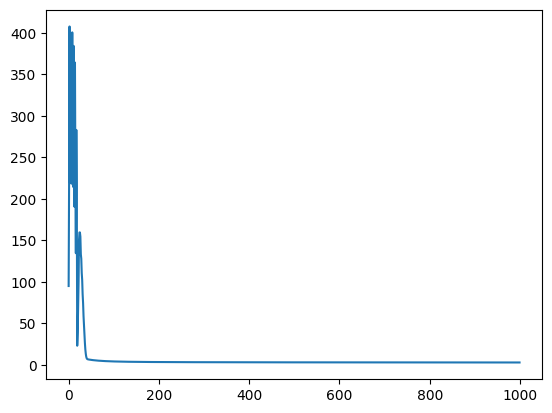

Accuracy (*100%): 70.77922077922078


In [20]:
gradient_val = logistic_gradient_descent(np.zeros((X_train.shape[1],1)), X_train, y_train, step_size=1, stop_cond=0.01, max_iterations=1000)
print("Gradient Descent (Logistic Regression) Final Value:", gradient_val[0], "over", gradient_val[1], "iterations.")
plt.plot([i for i in range(gradient_val[1])], gradient_val[2])
plt.show()

w_opt = gradient_val[0]

probabilities = sigmoid(X_test@w_opt)
predictions = (probabilities >= 0.5).astype(int)
accuracy = np.mean(predictions == y_test)
print("Accuracy (*100%):", accuracy * 100)


**Applying Gradient Descent for Support Vector Machine**

Gradient Descent (Momentum) Final Value: [9.89049183e-01 6.87550467e-03 6.51604841e-02 6.45381767e-02
 3.29404778e-02 3.13632719e-02 4.24450514e-02 7.46739751e-04
 4.45865409e-02] over 100000 iterations.


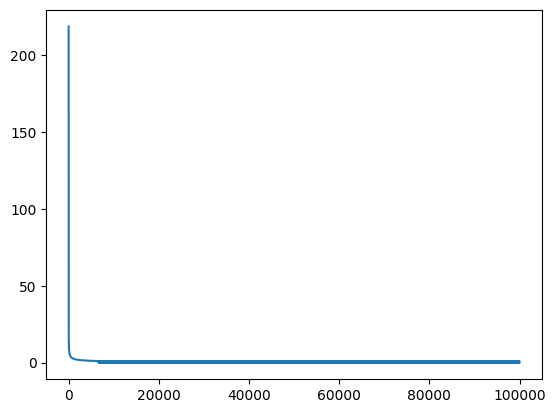

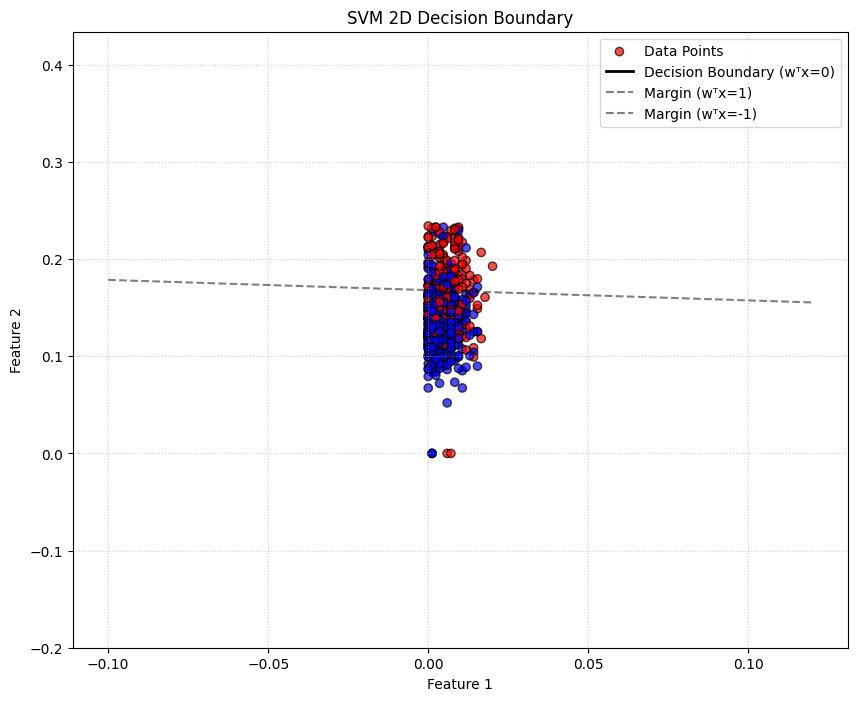

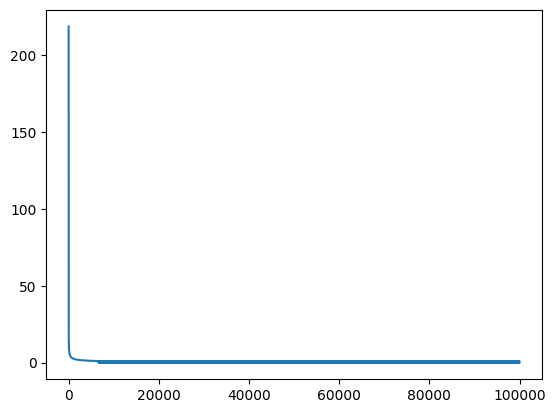

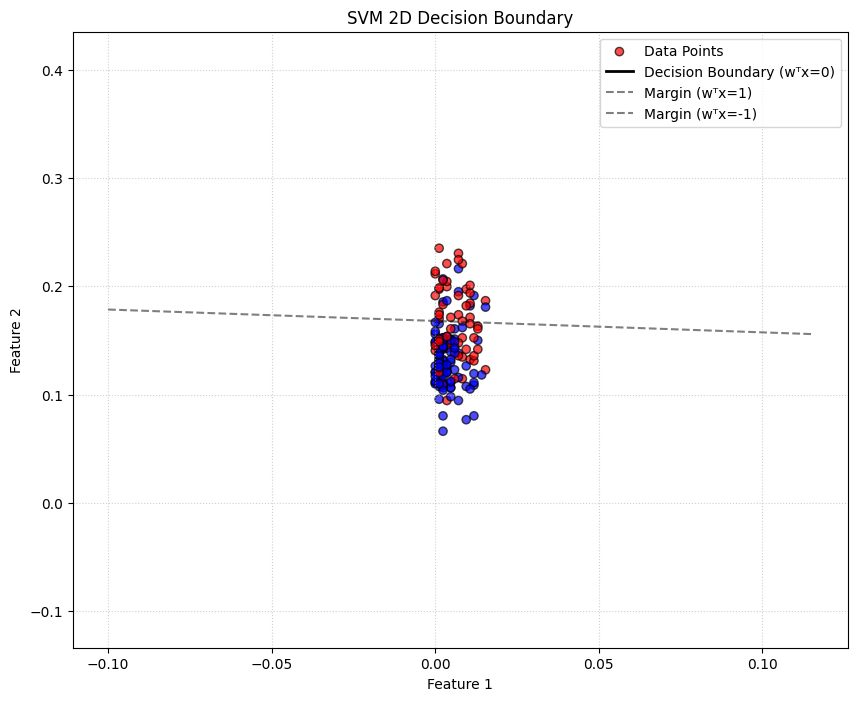

0.35714285714285715


In [21]:
subgradient_val = svm_subgradient_descent(np.zeros((X_train.shape[1],)), X_train, y_train, step_size=1, stop_cond=0.01, lambda_=1, max_iterations=100000)
print("Gradient Descent (Momentum) Final Value:", subgradient_val[0], "over", subgradient_val[1], "iterations.")
plt.plot([i for i in range(subgradient_val[1])], subgradient_val[2])
# plt.ylim(top=3.5, bottom=0)
plt.show()

bias = subgradient_val[0][0]
w1 = subgradient_val[0][1]
w2 = subgradient_val[0][2]

plt.figure(figsize=(10, 8))

plt.scatter(X_train[:, 1], X_train[:, 2], c=y_train, cmap='bwr', alpha=0.7, edgecolors='k', label='Data Points')

x1_range = np.linspace(X_train[:, 1].min() - 0.1, X_train[:, 1].max() + 0.1, 100)
x2_boundary = -(w1 * x1_range + bias) / w2

x2_margin_plus = -(w1 * x1_range + bias - 1) / w2
x2_margin_minus = -(w1 * x1_range + bias + 1) / w2

plt.plot(x1_range, x2_boundary, 'k-', linewidth=2, label='Decision Boundary (wᵀx=0)')
plt.plot(x1_range, x2_margin_plus, 'k--', alpha=0.5, label='Margin (wᵀx=1)')
plt.plot(x1_range, x2_margin_minus, 'k--', alpha=0.5, label='Margin (wᵀx=-1)')

plt.title(f'SVM 2D Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.ylim(X_train[:, 2].min() - 0.2, X_train[:, 2].max() + 0.2)

plt.show()

plt.plot([i for i in range(subgradient_val[1])], subgradient_val[2])
plt.show()
plt.close()

plt.figure(figsize=(10, 8))

plt.scatter(X_test[:, 1], X_test[:, 2], c=y_test, cmap='bwr', alpha=0.7, edgecolors='k', label='Data Points')

x1_range = np.linspace(X_test[:, 1].min() - 0.1, X_test[:, 1].max() + 0.1, 100)
x2_boundary = -(w1 * x1_range + bias) / w2

x2_margin_plus = -(w1 * x1_range + bias - 1) / w2
x2_margin_minus = -(w1 * x1_range + bias + 1) / w2

plt.plot(x1_range, x2_boundary, 'k-', linewidth=2, label='Decision Boundary (wᵀx=0)')
plt.plot(x1_range, x2_margin_plus, 'k--', alpha=0.5, label='Margin (wᵀx=1)')
plt.plot(x1_range, x2_margin_minus, 'k--', alpha=0.5, label='Margin (wᵀx=-1)')

plt.title(f'SVM 2D Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.ylim(X_test[:, 2].min() - 0.2, X_test[:, 2].max() + 0.2)

plt.show()

predictions=np.sign(X_test@subgradient_val[0])

accuracy=np.mean(predictions.flatten()==y_test.flatten())

print(accuracy)